# Qiskit + AQT port of the Braket / Rigetti notebook

This notebook ports the original AWS Braket / Rigetti workflow to **Qiskit + AQT**.

It:
1. Builds the same 2-qubit alternating-CNOT circuits.
2. Computes the expected output bitstring for each input/length pair.
3. Verifies the reference table on AQT's ideal offline simulator.
4. Submits a random batch to an AQT backend (simulator or hardware).
5. Computes the success probability for each circuit and plots the results.

Before using real AQT hardware, fill in `AQT_API_TOKEN` below and inspect `provider.backends()` to see the exact backend names available to your account.


In [2]:
# Install dependencies if needed
!pip install qiskit qiskit-aqt-provider pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 13.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 15.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [qiskit-aqt-provider]th0-python]


In [2]:
%pip install qiskit qiskit-aqt-provider

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 24.4 MB/s  0:00:00 eta 0:00:01
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 39.7 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.6 MB/s  0:00:00
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 208.7 MB/s  0:00

In [1]:
import itertools as it
import random
import time

import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aqt_provider import AQTProvider
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator


In [2]:
from qiskit import QuantumCircuit
import itertools as it
import random


def cnot_sequence(circuit_length, input_bits="00"):
    # 2 qubits, no classical bits yet (printing looks cleaner)
    qc = QuantumCircuit(2, name=f"cnot_len{circuit_length}_{input_bits}")

    # encode the input
    if input_bits[0] == "1":
        qc.x(0)
    if input_bits[1] == "1":
        qc.x(1)

    # create the CNOT sequence (same alternation as Braket)
    for idx in range(circuit_length):
        if idx % 2 == 0:
            qc.cx(0, 1)
        else:
            qc.cx(1, 0)

    return qc


possible_input_bits = ("00", "01", "10", "11")
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(it.product(possible_input_bits, possible_circuit_lengths))

# Pre-build a circuit pool (same idea as your Braket dict)
circuit_pool = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit_pool[(input_bits, circuit_length)] = cnot_sequence(
            circuit_length, input_bits=input_bits
        )


def generate_circuit_batch(size):
    random_keys = random.choices(possible_keys, k=size)
    return [(key, circuit_pool[key]) for key in random_keys]


print("EXAMPLE CIRCUIT BATCH")
print("_" * 24)
for key, circuit in generate_circuit_batch(5):
    print()
    print("input_bits={}, length={}".format(*key))
    print("-" * 24)
    print(circuit.draw("text"))  # Qiskit text diagram
    print("_" * 24)

EXAMPLE CIRCUIT BATCH
________________________

input_bits=10, length=1
------------------------
     ┌───┐     
q_0: ┤ X ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
________________________

input_bits=01, length=5
------------------------
               ┌───┐     ┌───┐     
q_0: ───────■──┤ X ├──■──┤ X ├──■──
     ┌───┐┌─┴─┐└─┬─┘┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├┤ X ├──■──┤ X ├──■──┤ X ├
     └───┘└───┘     └───┘     └───┘
________________________

input_bits=00, length=5
------------------------
          ┌───┐     ┌───┐     
q_0: ──■──┤ X ├──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├──■──┤ X ├
     └───┘     └───┘     └───┘
________________________

input_bits=11, length=3
------------------------
     ┌───┐     ┌───┐     
q_0: ┤ X ├──■──┤ X ├──■──
     ├───┤┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├┤ X ├──■──┤ X ├
     └───┘└───┘     └───┘
________________________

input_bits=10, length=1
------------------------
     ┌───┐     
q_0: ┤ X ├──■──
     └───┘┌─┴─┐
q_1: ─────

In [3]:
import time

class Timer:
    def __init__(self, description):
        self.description = description
    def __enter__(self):
        print(f"{self.description} ...", end="")
        self.start = time.time()
        return self
    def __exit__(self, type, value, traceback):
        self.end = time.time()
        print(f" complete: {self.end - self.start:.3f}s")
        return False

In [4]:
from qiskit_aqt_provider import AQTProvider
from qiskit import transpile

s3_folder = ("amazon-braket-eng-dev", "yuval_mwe_preliminary")  # unused by AQT

AQT_API_TOKEN = ""
REFERENCE_BACKEND_NAME = "offline_simulator_no_noise"

provider = AQTProvider(AQT_API_TOKEN)
aqt_simulator = provider.get_backend(REFERENCE_BACKEND_NAME)

reference_table = {}

for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:

        circuit_to_simulate = circuit_pool[(input_bits, circuit_length)].copy()
        circuit_to_simulate.measure_all()
        # circuit_to_simulate.add_register(__import__("qiskit").ClassicalRegister(2, "c"))
        # circuit_to_simulate.measure(0, 1)  # qubit 0 -> classical bit 1 (MSB)
        # circuit_to_simulate.measure(1, 0)  # qubit 1 -> classical bit 0 (LSB)

        print(f"Starting job: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")

        with Timer("AQT simulator"):
            # IMPORTANT: convert cx to AQT basis {rz, r, rxx}
            circuit_to_simulate = transpile(
                circuit_to_simulate,
                backend=aqt_simulator,
                optimization_level=3
            )

            task = aqt_simulator.run(circuit_to_simulate, shots=1)

            result = task.result().get_counts()
            correct_output = list(result.keys())[0]
            correct_output = correct_output[::-1]  # "q1q0" -> "q0q1"

            reference_table[(input_bits, circuit_length)] = correct_output

Starting job: input_bits=00, circuit_length=1... AQT simulator ...

100%|██████████| 1/1 [00:00<00:00, 3206.65it/s]


 complete: 0.058s
Starting job: input_bits=00, circuit_length=2... AQT simulator ...

100%|██████████| 1/1 [00:00<00:00, 2394.01it/s]


 complete: 0.016s
Starting job: input_bits=00, circuit_length=3... AQT simulator ...

...

 complete: 0.024s
Starting job: input_bits=11, circuit_length=5... AQT simulator ...

100%|██████████| 1/1 [00:00<00:00, 5084.00it/s]


 complete: 0.021s
Starting job: input_bits=11, circuit_length=6... AQT simulator ...

100%|██████████| 1/1 [00:00<00:00, 5932.54it/s]

 complete: 0.015s


In [5]:
for input_bits in possible_input_bits:
    reference = [input_bits] + [reference_table[(input_bits, l)] for l in possible_circuit_lengths]
    print("{} | {} {} {} {} {} {}".format(*reference))

00 | 00 00 00 00 00 00
01 | 01 11 10 10 11 01
10 | 11 01 01 11 10 10
11 | 10 10 11 01 01 11


In [30]:
from qiskit import transpile

#test_batch = generate_circuit_batch(1000)
test_batch = generate_circuit_batch(100)

EXECUTION_BACKEND_NAME = "simulator_noise"
execution_backend = provider.get_backend(EXECUTION_BACKEND_NAME)

# Build measured circuits in same order as test_batch
test_circuits = []
for key, circuit in test_batch:
    qc = circuit.copy()
    qc.measure_all()
    #qc.add_register(__import__("qiskit").ClassicalRegister(2, "c"))
    #qc.measure(0, 1)  # qubit 0 -> classical bit 1 (MSB)
    #qc.measure(1, 0)  # qubit 1 -> classical bit 0 (LSB)
    test_circuits.append(qc)

# Transpile to AQT basis so 'cx' is decomposed into {rz, r, rxx}
transpiled_batch = transpile(test_circuits, backend=execution_backend, optimization_level=3)

# Submit ONE circuit per job (Braket-like: 100 tasks -> 100 IDs)
tasks = []
task_id = []

for (key, _), qc in zip(test_batch, transpiled_batch):
    task = execution_backend.run(qc, shots=100)
    tasks.append(task)
    task_id.append(task.job_id())

print("task_id count:", len(task_id))
print(task_id)

task_id count: 100
['2e7daf9e-9270-4e0f-9d7e-171b43fb3742', 'b8d2c4c7-1038-4c76-b82a-a32bd8c5d365', '9d870bbe-fbe4-46b1-bbe6-4fd8dd517ed0', 'b82f6355-e225-44fc-9842-537c92e64e4f', 'add3b1f0-7601-4a7e-a8b8-1d5f32a76d36', '1876122f-46f5-47c8-bbca-48ad5421aef6', 'ec8d4191-e731-4c07-b78f-e5e2ddbb0e8d', '05f4f693-a37b-436e-b367-9e3386b0c36d', 'd9190dbd-4681-4d2f-8e7f-f0acdf547f65', '88537e82-2edc-49d8-9c24-ca1feaf51996', '88e17786-d6be-4880-b035-7e8d5d3fa524', 'a43c4b0a-07a4-4f1d-ba40-2cc67c5497cf', '93ccf7da-4d09-4848-ae21-043abac5b1a8', '28a1b57c-c181-4238-b2f0-68b99baa69cc', 'add75d12-567b-49d0-adfb-96b263c420c6', '9c5ff79e-91f1-41f6-b588-248cd9c0c1f5', '4d22b656-32da-4820-a186-5033d3105f87', 'c8305373-dd8f-4797-b611-0d5894ffe2f7', '3b9950bb-5123-4747-b7bc-312ee287a839', 'f89b115b-4611-4f53-8627-786e03c97b9c', '05d1dcbe-1f9c-487c-9e9f-6f661647f4ce', 'aa1533b1-ef6c-41d6-a443-81a5940c5f18', 'b7cd8112-28d8-4598-a4e1-5adbfd9245a4', '928ea8c8-26fd-4883-8568-2e4f7e4128ee', '327f8101-f79d-41f8-

In [31]:
state_list = []

with Timer("Fetching the state takes super long..."):
    for k in range(len(tasks)):
        state = tasks[k].status()                  # Qiskit/AQT equivalent of Braket .state()
        state = state.name if hasattr(state, "name") else str(state)  # make it a string like "QUEUED"
        state_list += [state]
        print(f"Task {k:>3}: {state:<10}", end="\r")
    print("State fetch", end=" ")

number_of_tasks_still_queued = sum(1 if state_list[k] == 'QUEUED' else 0
                                   for k in range(len(state_list)))

if number_of_tasks_still_queued == 0:
    print("All tasks complete!")
else:
    print(f"Still waiting on {number_of_tasks_still_queued} tasks.")

State fetch  complete: 17.382s long... ...Task   0: DONE      
All tasks complete!


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import time

data = []

for idx in range(len(tasks)):
    print(idx)
    the_task   = tasks[idx]
    task_id    = the_task.job_id()
    the_result = None

    # Approximate createdAt/endedAt using local timestamps around result() fetch
    start_time = pd.to_datetime(time.time(), unit="s", utc=True)
    the_result = the_task.result()
    end_time   = pd.to_datetime(time.time(), unit="s", utc=True)
    elapsed_time = end_time - start_time

    batch_member   = test_batch[idx]
    circuit_key    = batch_member[0]
    input_bits     = circuit_key[0]
    circuit_length = circuit_key[1]

    the_result

    # Qiskit: counts instead of measurement_probabilities
    # get_counts() may return keys like "q1q0" for 2 qubits; convert to "q0q1"
    counts_raw = the_result.get_counts()  # one circuit per job, so no index needed

    measurement_probabilities = {}
    total_shots = sum(counts_raw.values()) if counts_raw else 0

    if total_shots > 0:
        for bitstr, ct in counts_raw.items():
            measurement_probabilities[bitstr[::-1]] = ct / total_shots  # normalize + flip ordering
            #measurement_probabilities[bitstr] = ct / total_shots

    correct_output      = reference_table[circuit_key]
    print('correct_output: ', correct_output)
    success_probability = measurement_probabilities.get(correct_output, 0.0)
    print('success_probability: ', success_probability)

    data.append((task_id,
                 input_bits,
                 circuit_length,
                 start_time,
                 end_time,
                 elapsed_time,
                 success_probability))

data = pd.DataFrame(data, columns=['id_string',
                                   'input_bits',
                                   'circuit_length',
                                   'start_time',
                                   'end_time',
                                   'elapsed_time',
                                   'success_probability'])

0


100%|██████████| 1/1 [00:00<00:00,  6.08it/s]


correct_output:  00
success_probability:  0.99
1


100%|██████████| 1/1 [00:00<00:00,  6.01it/s]


correct_output:  10
success_probability:  0.99
2


...

correct_output:  01
success_probability:  1.0
98


100%|██████████| 1/1 [00:00<00:00,  6.04it/s]


correct_output:  00
success_probability:  0.97
99


100%|██████████| 1/1 [00:00<00:00,  6.09it/s]

correct_output:  01
success_probability:  0.95


In [23]:
idx = 5  # pick a failing one
circuit_key = test_batch[idx][0]
correct_output = reference_table[circuit_key]

the_result = tasks[idx].result()
counts_raw = the_result.get_counts()

print("circuit_key:", circuit_key)
print("correct_output (from reference_table):", correct_output)
print("counts_raw:", list(counts_raw.keys())[0][::-1], counts_raw.values())
print("most_likely:", max(counts_raw, key=counts_raw.get))

100%|██████████| 1/1 [00:00<00:00, 611.95it/s]

circuit_key: ('10', 5)
correct_output (from reference_table): 10
counts_raw: 11 dict_values([1, 1, 98])
most_likely: 01


In [33]:
data

,id_string,input_bits,circuit_length,start_time,end_time,elapsed_time,success_probability
0,2e7daf9e-9270-4e0f-9d7e-171b43fb3742,00,2,2026-03-27 17:50:24.141292334+00:00,2026-03-27 17:50:24.311088800+00:00,0 days 00:00:00.169796466,0.99
1,b8d2c4c7-1038-4c76-b82a-a32bd8c5d365,10,6,2026-03-27 17:50:24.311723709+00:00,2026-03-27 17:50:24.484036446+00:00,0 days 00:00:00.172312737,0.99
2,9d870bbe-fbe4-46b1-bbe6-4fd8dd517ed0,10,2,2026-03-27 17:50:24.484675169+00:00,2026-03-27 17:50:24.654553890+00:00,0 days 00:00:00.169878721,0.96
3,b82f6355-e225-44fc-9842-537c92e64e4f,10,6,2026-03-27 17:50:24.655696630+00:00,2026-03-27 17:50:24.826149464+00:00,0 days 00:00:00.170452834,1.00
4,add3b1f0-7601-4a7e-a8b8-1d5f32a76d36,10,1,2026-03-27 17:50:24.826763868+00:00,2026-03-27 17:50:24.995290279+00:00,0 days 00:00:00.168526411,0.99
...,...,...,...,...,...,...,...
95,ceb31571-e90d-4521-b487-7460a2dc592d,00,2,2026-03-27 17:50:40.522468567+00:00,2026-03-27 17:50:40.692766905+00:00,0 days 00:00:00.170298338,0.97
96,668f906c-81ff-4150-83ff-79584e41aaa6,01,6,2026-03-27 17:50:40.693466902+00:00,2026-03-27 17:50:40.867775679+00:00,0 days 00:00:00.174308777,0.99
97,966c4840-1146-44ae-9590-e7c066172cc0,01,6,2026-03-27 17:50:40.868252277+00:00,2026-03-27 17:50:41.038995028+00:00,0 days 00:00:00.170742751,1.00
98,9fe4a9b5-8321-454e-bc68-662963555761,00,3,2026-03-27 17:50:41.039582968+00:00,2026-03-27 17:50:41.209418535+00:00,0 days 00:00:00.169835567,0.97


In [ ]:
data.to_csv('aqt_03_27_26.csv', index=False)

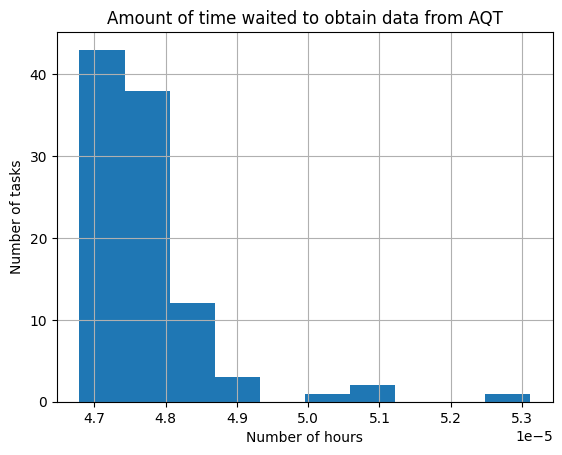

In [34]:
data['elapsed_time_hours'] = data['elapsed_time'].dt.total_seconds() / 3600
data['elapsed_time_hours'].hist()
plt.xlabel("Number of hours")
plt.ylabel("Number of tasks")
plt.title("Amount of time waited to obtain data from AQT")
plt.show()

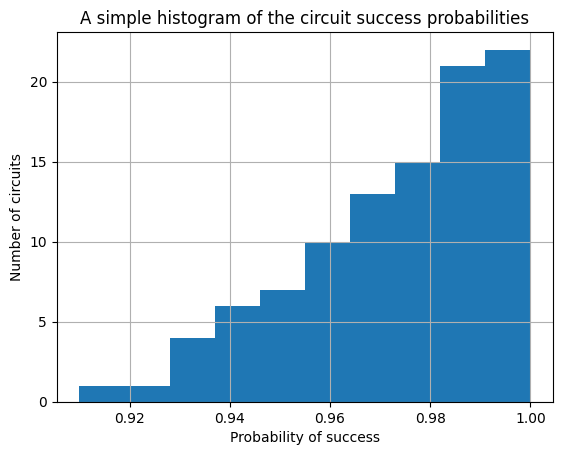

In [35]:
data['success_probability'].hist()
plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("A simple histogram of the circuit success probabilities")
plt.show()
     


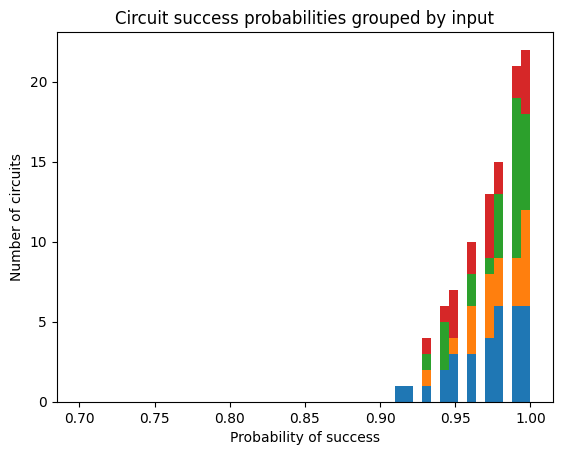

In [36]:
plt.hist([df["success_probability"] for input_bits, df in data.groupby("input_bits")],
          bins=50, range=(0.7, 1.0), stacked=True)

plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("Circuit success probabilities grouped by input")
plt.show()

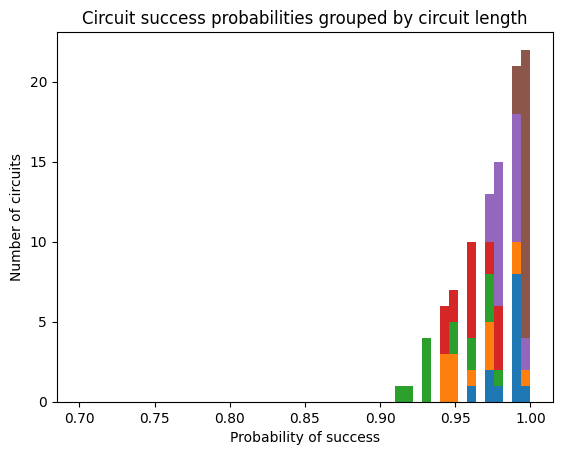

In [37]:
plt.hist([df["success_probability"] for input_bits, df in data.groupby("circuit_length")],
          bins=50, range=(0.7, 1.0), stacked=True)

plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("Circuit success probabilities grouped by circuit length")
plt.show()

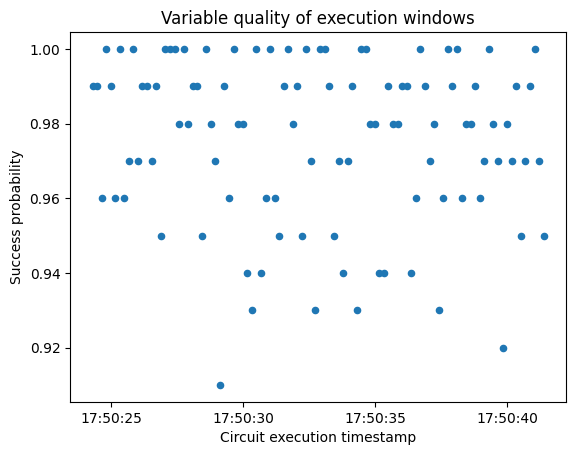

In [38]:
data.plot.scatter(x="end_time", y="success_probability")
plt.xlabel("Circuit execution timestamp")
plt.ylabel("Success probability")
plt.title("Variable quality of execution windows")
plt.show()
     